In [1]:
%matplotlib widget
from ipywidgets import *
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use('dark_background')

fontsize = 16
mpl.rcParams.update(
    {
        "text.usetex": True,
        "figure.figsize": (9, 6),
        "figure.autolayout": True,
        "font.family": "serif",
        "font.serif": "georgia",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
    }
)

# 1. Introduction

## 1.1. What is the NIF?

The NIF(National Ignition Facility) is home of the world's highest-energy laser system, in California. The facility is funded by the DOE under the nuclear security administration, but it conducts experiments in other fields(materials sciences, weapons physics, and high energy density) as well. For fusion physics, the NIF is able to compress and heat a deuterium-tritium target enough to generate a fusion reaction. The NIFs big milestone was when they produced enough energy to sustain further fusion, meaning it produced more energy than the laser energy delivered to the target, though not more than the total electrical energy required to operate the system. At this point, the fusion reactions became self-heating because the fusion produced alpha particles, which became trapped in the plasma and depsoited energy back into the fuel. 

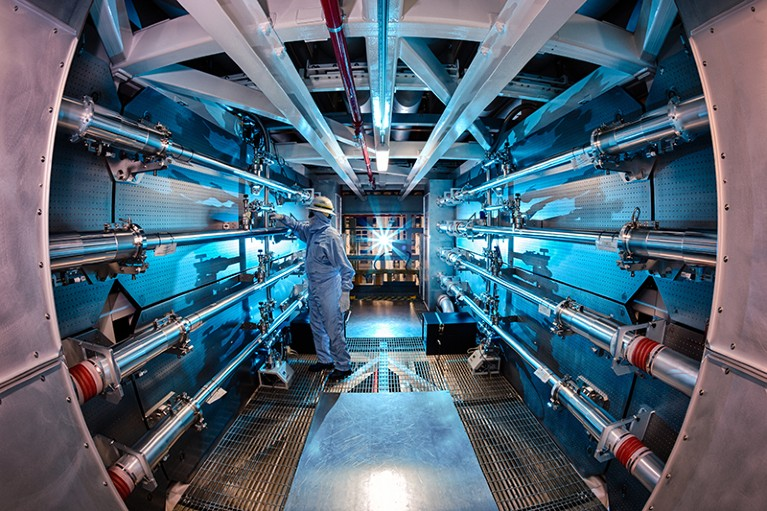

## 1.2. The Laser

The NIF uses 192 Nd:glass laser beams that are amplified and delievered onto a tiny target(the deuterium-tritium). The light emmited is at 1053 nm, amplified through Nd:phosphate glass slabs, and then converted to 351nm using nonlinear crystals(KDP/DKDP crystals). It produces ~1.8MJ pulsed energy and 500TW of peak power. 

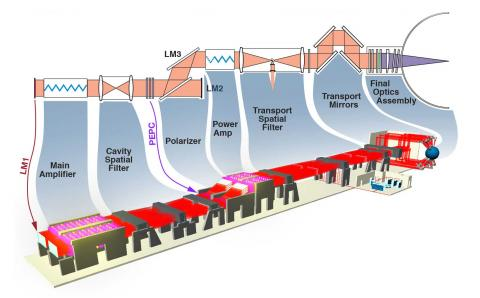

## 1.3. Framework

1. Brief Fusion Background
2. What are pulsed lasers?
3. What is pulse shaping?
4. How does the NIF amplify their lasers?

# 2. Fusion 101 

Nuclear fusion is the process in which light atomic nuclei combine to form a heavier nucleus, releasing energy. The reaction most relevant for NIFs fusion is deuterium–tritium (DT) fusion:
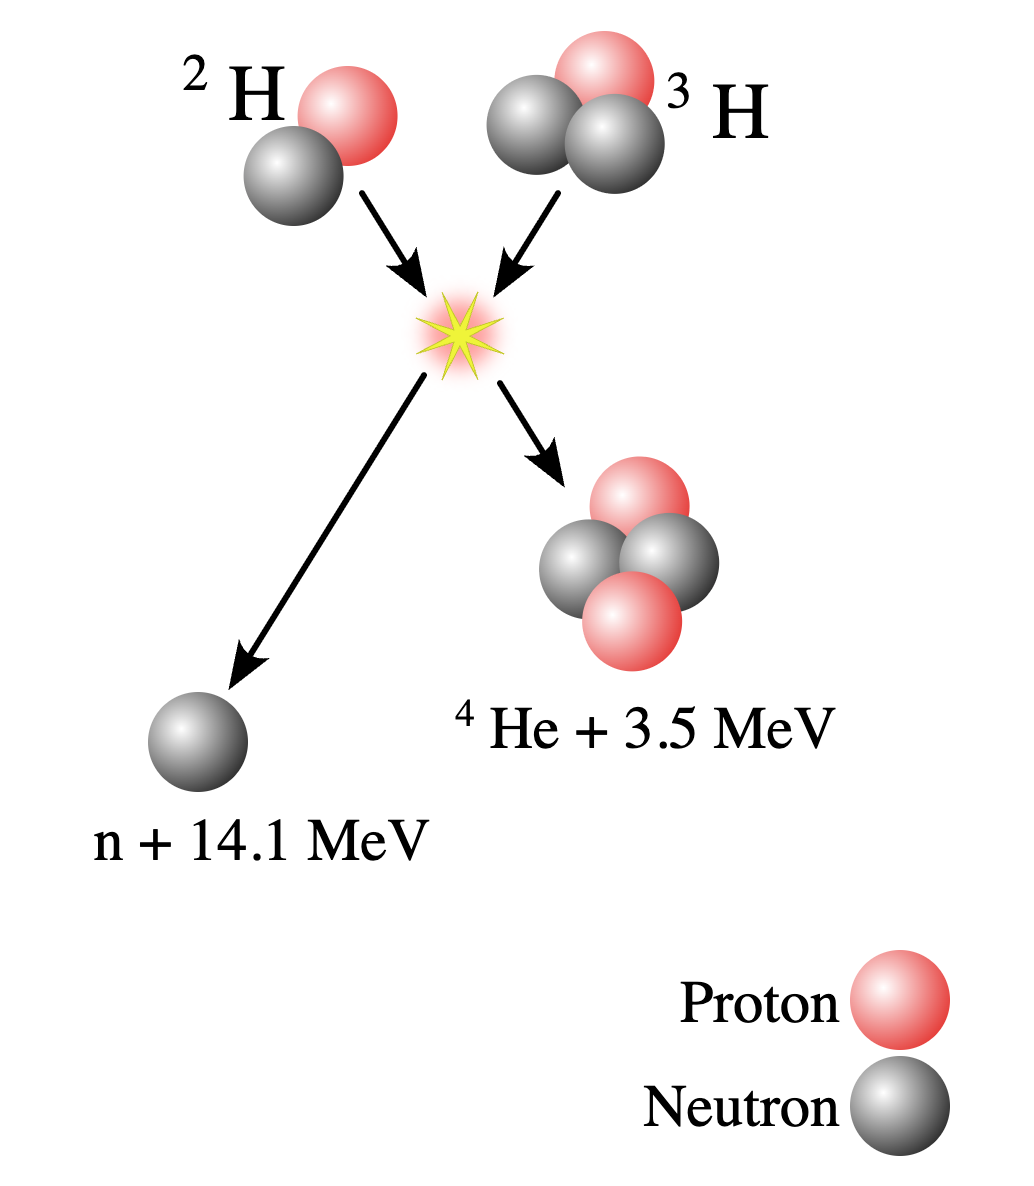

We get a helium nucleus(alpha particle) and a high-energy neutron out of the reaction. NIF works with inertial confinement fusion, which focuses on having a small capsule of DT fuel rapidly compress using laser-driven radiation. The laser energy is converted into X-rays which irradiate the capsule. The outer layer of the capsule explode, causing an inward force to compress the fuel, igniting the fusion reaction. 
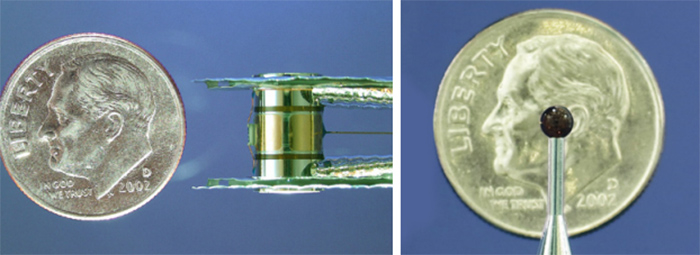

# 3. Pulsed Lasers

We spent most of this class focusing on continuous lasers, which is what is used in LIGO, but to understand how the NIF achieves such high power we need to first understand what pulsed lasers are.

## 3.1. Fundamental Equations

Pusled lasers concentrate energy into a finite time window, so the instantaneous power can be found:
\begin{align}
P(t) = \frac{dE}{dt}
\end{align}
Conversely, the total pulse energy is:
\begin{align}
E = \int_{-\infty}^{\infty} P(t),dt
\end{align}
For duration $\tau$, the scaling of power is
\begin{align}
P_{\text{peak}} \sim \frac{E}{\tau}
\end{align}
This is the main idea behind pulsed lasers: for some fixed energy, reducing the pulse duration increases the peak power. 


## 3.2. Limitations

When thinking about damage thresholds, we often think about the peak intensity of our laser. For NIF, they tend to be worried about the balance of their fluence - energy delivered per unit area.
\begin{align}
F = \frac{E}{A} \quad \text{(J/m}^2\text{)}
\end{align}
As with intensity, high fluence can damage optics but they need to deliver enough energy to the system to properly heat it.

## 3.3. Continuous Vs. Pulsed Power

A continuous-wave laser cannot reach the same peak powers as pulsed systems like the NIF because it must deliver energy at the same rate it is generated, whereas pulsed lasers decouple energy storage from energy delivery in time.
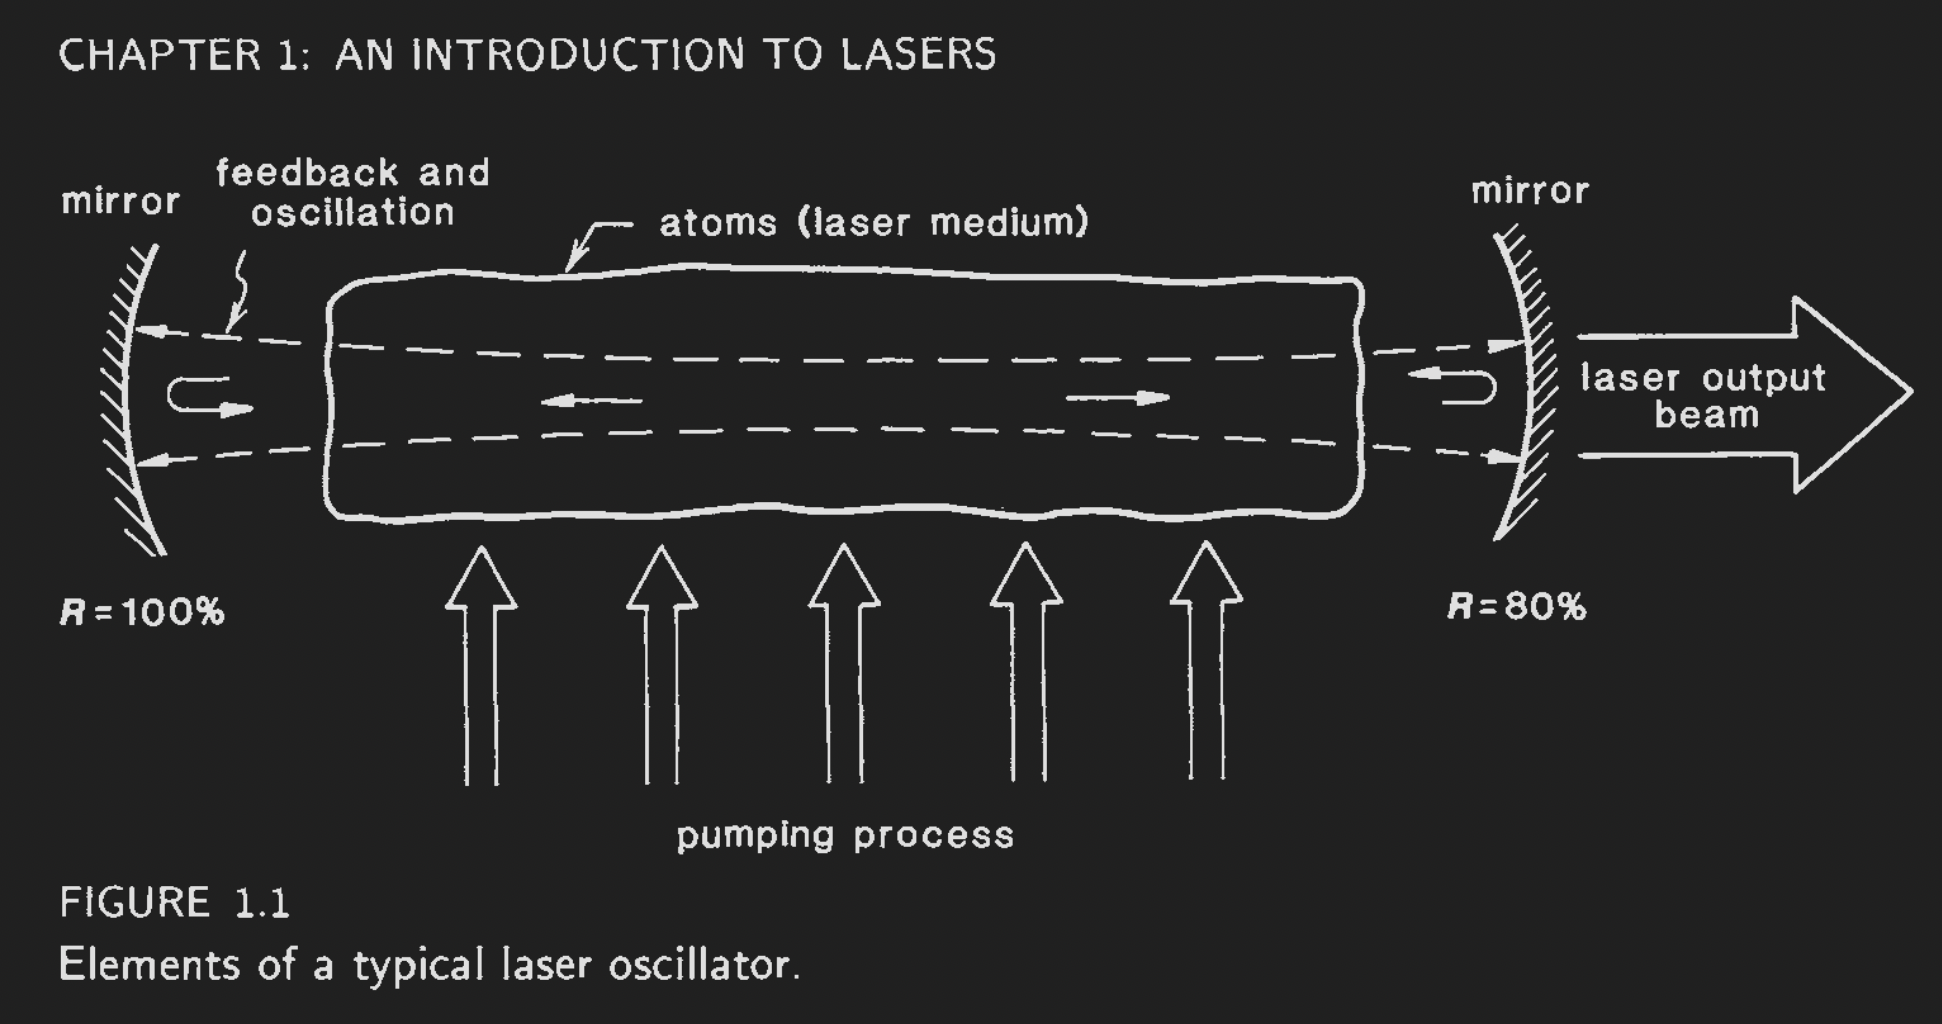

1. First, the system stores energy gradually in the gain medium. In CW lasers, energy is extracted after creation so the output power is limited by the pump rate. In pulsed, energy is stored for ~milliseconds and dumped at ~nanoseconds.
2. Energy is released in a controlled short time window. Since power scales with $\frac{1}{\tau}$, power is automatically higher for pusled lasers with the same base energy.
3. Fluence is kept below damage thresholds until the final stages. In CW optics, there is continuous heating leading to thermal damages, so we are often limited by average power handling. For pulsed lasers, optics are able to survive much more power beacuse the system can cool between shots. 


## 3.4. Modeling a Gaussian Pulse

NIF does not use gaussian pulses(more on that later) but it is a good starting place to model them. 

We will need to solve for the power of a Gaussian pulse starting from: 
\begin{align}
P(t) = P_0 \exp(-at^2)
\end{align}
where $P_0$ is the peak power and $a$ is the width parameter. 

The FWHM is defined so:
\begin{align}
P(\frac{\tau_{FWHM}}{2}) = \frac{P_0}{2} \\
\frac{P_0}{2} = P_0 \exp(-a(\frac{\tau_{FWHM}}{2})^2)
\end{align}
Once you cancel $P_0$ and find the natural log you can solve for a and are left with:
\begin{align}
P(t) = P_0 \exp\left[-4\ln(2)\left(\frac{t}{\tau_{\mathrm{FWHM}}}\right)^2\right]
\end{align}

The total energy is 
\begin{align}
E = \int_{-\infty}^{\infty} P(t)\, dt \\
E = \int_{-\infty}^{\infty} P_0 \exp\left[-4\ln(2)\left(\frac{t}{\tau}\right)^2\right] dt \\
E = P_0 \, \tau \sqrt{\frac{\pi}{4\ln(2)}} \\
P_0 = \frac{E}{\tau} \sqrt{\frac{4\ln(2)}{\pi}} \\
\end{align}

interactive(children=(FloatSlider(value=10.0, description='E (J):', min=0.1), FloatSlider(value=5.0, descripti…

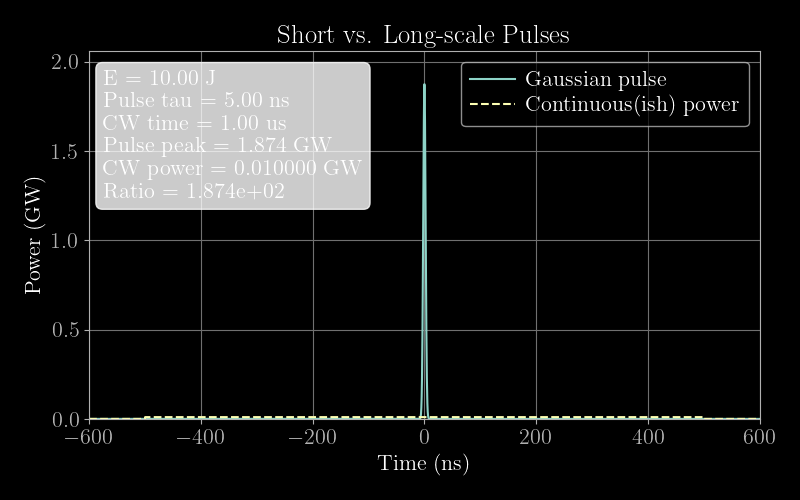

In [4]:
def gaussian_power(t, E, tau_fwhm):
    P0 = E / (tau_fwhm * np.sqrt(np.pi / (4 * np.log(2))))
    return P0 * np.exp(-4 * np.log(2) * (t / tau_fwhm) ** 2)

def cw_power_window(t, E, tau_cw):
    Pcw = E / tau_cw
    return np.where(np.abs(t) <= tau_cw / 2, Pcw, 0.0)

# Initial parameters
E0 = 10.0
tau_ns0 = 5.0
cw_us0 = 1.0

tau_pulse0 = tau_ns0 * 1e-9
tau_cw0 = cw_us0 * 1e-6

tmax0 = max(6 * tau_pulse0, 0.6 * tau_cw0)
t = np.linspace(-tmax0, tmax0, 4000)

P_pulse0 = gaussian_power(t, E0, tau_pulse0)
P_cw0 = cw_power_window(t, E0, tau_cw0)

fig, ax = plt.subplots(figsize=(8, 5))

line_pulse, = ax.plot(t * 1e9, P_pulse0 / 1e9, label="Gaussian pulse")
line_cw, = ax.plot(t * 1e9, P_cw0 / 1e9, "--", label="Continuous(ish) power")

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Power (GW)")
ax.set_title("Short vs. Long-scale Pulses")
ax.grid(True)
ax.legend()

text_box = ax.text(
    0.02, 0.95, "",
    transform=ax.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

def update_pulse_vs_cw(E_slider=E0, tau_ns_slider=tau_ns0, cw_us_slider=cw_us0):
    tau_pulse = tau_ns_slider * 1e-9
    tau_cw = cw_us_slider * 1e-6

    tmax = max(6 * tau_pulse, 0.6 * tau_cw)
    t = np.linspace(-tmax, tmax, 4000)

    P_pulse = gaussian_power(t, E_slider, tau_pulse)
    P_cw = cw_power_window(t, E_slider, tau_cw)

    line_pulse.set_xdata(t * 1e9)
    line_pulse.set_ydata(P_pulse / 1e9)

    line_cw.set_xdata(t * 1e9)
    line_cw.set_ydata(P_cw / 1e9)

    ax.set_xlim(t[0] * 1e9, t[-1] * 1e9)

    ymax = 1.1 * max(np.max(P_pulse / 1e9), np.max(P_cw / 1e9))
    ax.set_ylim(0, ymax)

    peak_pulse = np.max(P_pulse)
    peak_cw = np.max(P_cw)

    text_box.set_text(
        f"E = {E_slider:.2f} J\n"
        f"Pulse tau = {tau_ns_slider:.2f} ns\n"
        f"CW time = {cw_us_slider:.2f} us\n"
        f"Pulse peak = {peak_pulse/1e9:.3f} GW\n"
        f"CW power = {peak_cw/1e9:.6f} GW\n"
        f"Ratio = {peak_pulse/peak_cw:.3e}"
    )

    fig.canvas.draw_idle()

interact(
    update_pulse_vs_cw,
    E_slider=FloatSlider(
        value=E0, min=0.1, max=100, step=0.1,
        description="E (J):", continuous_update=True
    ),
    tau_ns_slider=FloatSlider(
        value=tau_ns0, min=0.1, max=50, step=0.1,
        description="tau (ns):", continuous_update=True
    ),
    cw_us_slider=FloatSlider(
        value=cw_us0, min=0.1, max=10, step=0.1,
        description="CW (us):", continuous_update=True
    ),
)

plt.show()

## 3.5. High Power Jusification
We understand how the NIF reaches such high power(and we will talk about the optical pathing that allows this to physically happen), but why does it need to? Inertial confinement fusion must occur on a very short timescale. The fuel capsule is confined only by its own inertia, so the laser must compress and heat it before it has time to expand. A rough confinement time can be estimated as
\begin{align}
\tau_{\text{implosion}} \sim \frac{R}{v}
\end{align}
where $R$ is the capsule radius and $v$ is the implosion velocity. For a millimeter-scale target and implosion velocities on the order of $10^5$ m/s, this gives a timescale of only a few nanoseconds.

If megajoule-scale energy must be delivered within a few nanoseconds, then the required power is

\begin{align}
P \sim \frac{E}{\tau}
\end{align}

which naturally leads to peak powers in the $10^{14}$ to $10^{15}$ W range. This is why NIF must operate with extremely intense pulsed lasers, needing to supply enough energy fast enough to cause the compression.

Unlike many other pulsed laser configurations, NIF focuses on huge energy(megajoule-scale) over a modest pulse duration(nanosecond) rather than having picosecond pulses at lower energies. 

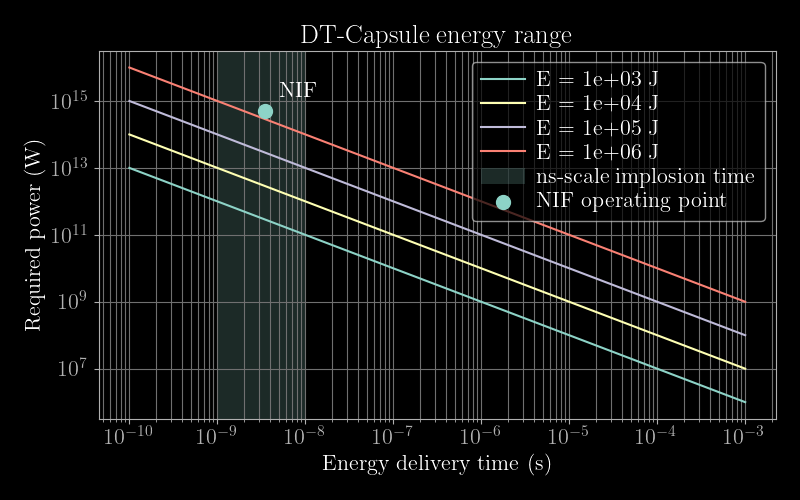

In [5]:
import numpy as np
import matplotlib.pyplot as plt

energies = [1e3, 1e4, 1e5, 1e6]   # J
times = np.logspace(-10, -3, 500) # 0.1 ns to 1 ms

plt.figure(figsize=(8, 5))

# E/t plots
for E in energies:
    P = E / times
    plt.loglog(times, P, label=f"E = {E:.0e} J")

# NIF target band size
plt.axvspan(1e-9, 1e-8, alpha=0.2, label="ns-scale implosion time")

# NIF point
E_nif = 1.8e6    # J
tau_nif = 3.5e-9 # s
P_nif = E_nif / tau_nif

plt.scatter(tau_nif, P_nif, s=100, marker='o', zorder=5, label="NIF operating point")

plt.annotate(
    "NIF",
    (tau_nif, P_nif),
    textcoords="offset points",
    xytext=(10, 10)
)

plt.xlabel("Energy delivery time (s)")
plt.ylabel("Required power (W)")
plt.title("DT-Capsule energy range")
plt.grid(True, which="both")
plt.legend()
plt.show()

# 4. Pulse Shaping

At NIF, the main driver is **high pulse energy plus nanosecond pulse shaping**. This means it has some complex time profile rather than a Gaussian pulse. Other high power laser systems use diferent drivers, such as pulse compression.
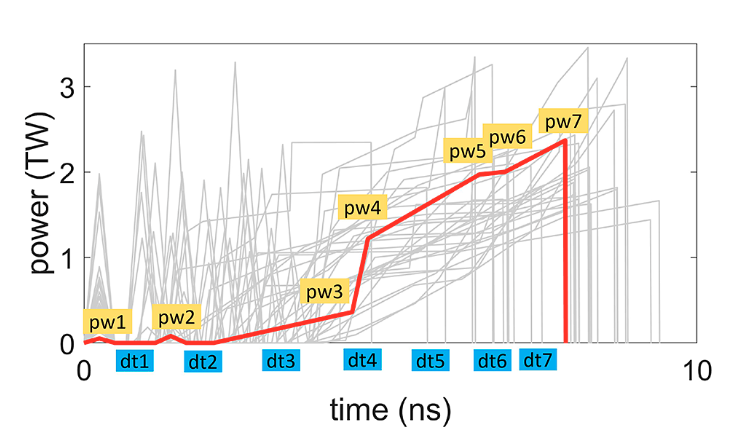

According to the NIF User Guide, users request a desired target pulse shape and energy, and that request is converted to a **Master Oscillator Room** waveform after accounting for distortions caused by **main laser gain saturation** and **frequency conversion**.[5] 

Using the example of fusion again, the goal is to compress a deutreium-tridium capsule, heat it, and avoid any instabilities. This requires a very specific pulse shape:
1. **Shock timing**

When the laser hits the DT, shock waves are created that travel inward. To avoid any energy being wasted, they shape their pulses to have multiple shocks arrive at the center of the capsule simulatneously.

2. **Preheating**

If a large amount of energy is immeditely dumped into the capsules the fuel begins to heat and expand before it is compressed by the outward explosion of the capsule. NIF sends in some low-power lasers to "prime" the DT capsule and gently start the compression process.
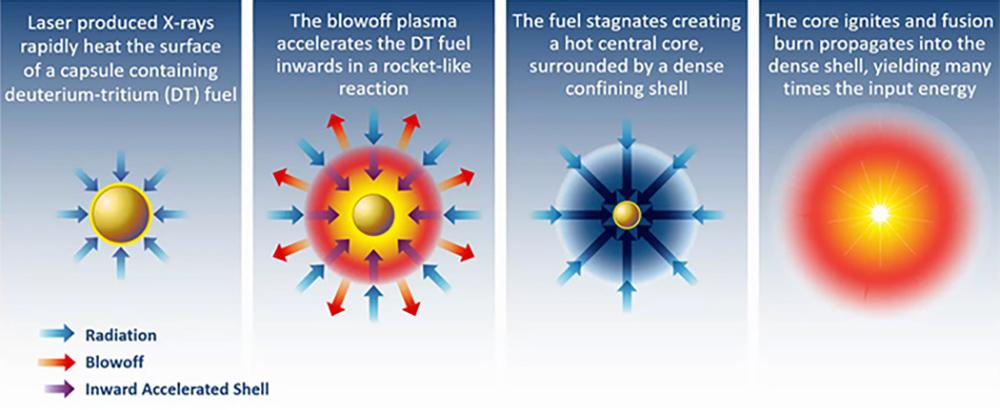

3. **Main Compression**

After the low power pusles, NIF ramps up the power to their main drive status to cause the above reaction.

# 5. Optical Pathing

Finally, I want to discuss how we get from an initial laser to this insanely high power.
## 5.1 Master Oscillator
The beam begins with a very low-energy pulse that has the pulse shaping discussed before. Here we start with 48 single beams that are eventually split to the >190 beams finally delievered to the target.
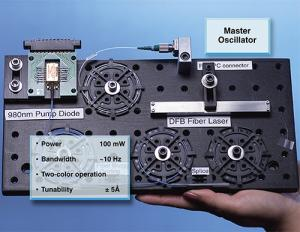

The original laser comes from a fiber laser.
## 5.2 Pre-Amplifer Module
The "PAM" boosts energies from the nJ region to the scale of Joules using fiber amplifieres and small soild-state amplifiers. The nJ beam coming from the master oscillator is not powerful or stable enough to go into the main amplification stage, so it goes through low noise fiber amplifiers and then Nd:glass rod amplifiers. It is after this stage that beam analysis is done. 
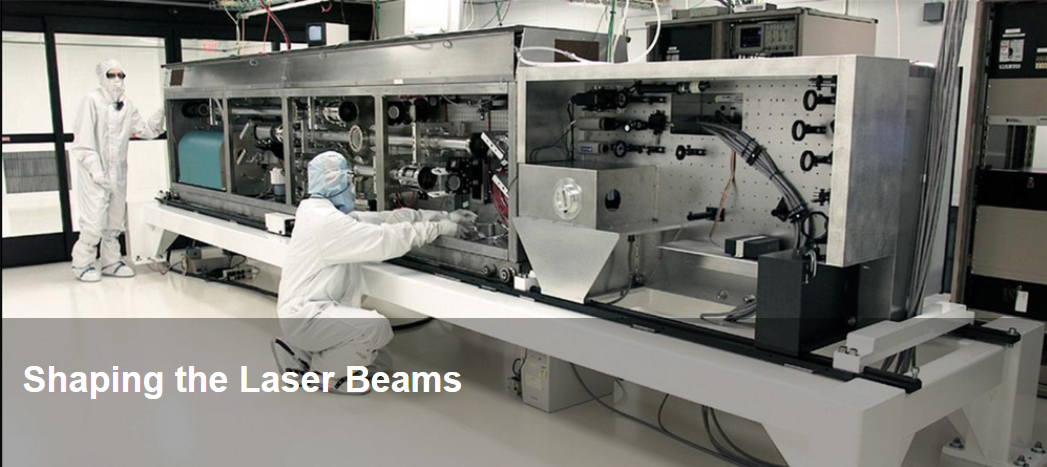

Question: Why are their optics tables vertical? I couldn't find a good explanation online.
## 5.3 Beam Splitting
The ~J energy beam is them split into 192 identical beams through a series of beam splitters.
## 5.4 Main Amplifier
Here, each beam passes through ~16 slabs of neodymium doped phosopate glass slabs:
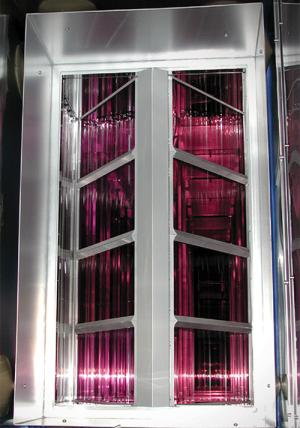

The actual amplification is done using "flashlamp" pumping. What physically happens is flashlamps dump energy into the glass to excite the Nd ions to cause population inversion. Each slab has some maximum gain to avoid optical damage so the beam passes through this stage 4 times(effectively like a laser cavity). Throughout this whole process, the beam goes through many spatial filtering stages such as pinhole filters to maintain the beam clarity.
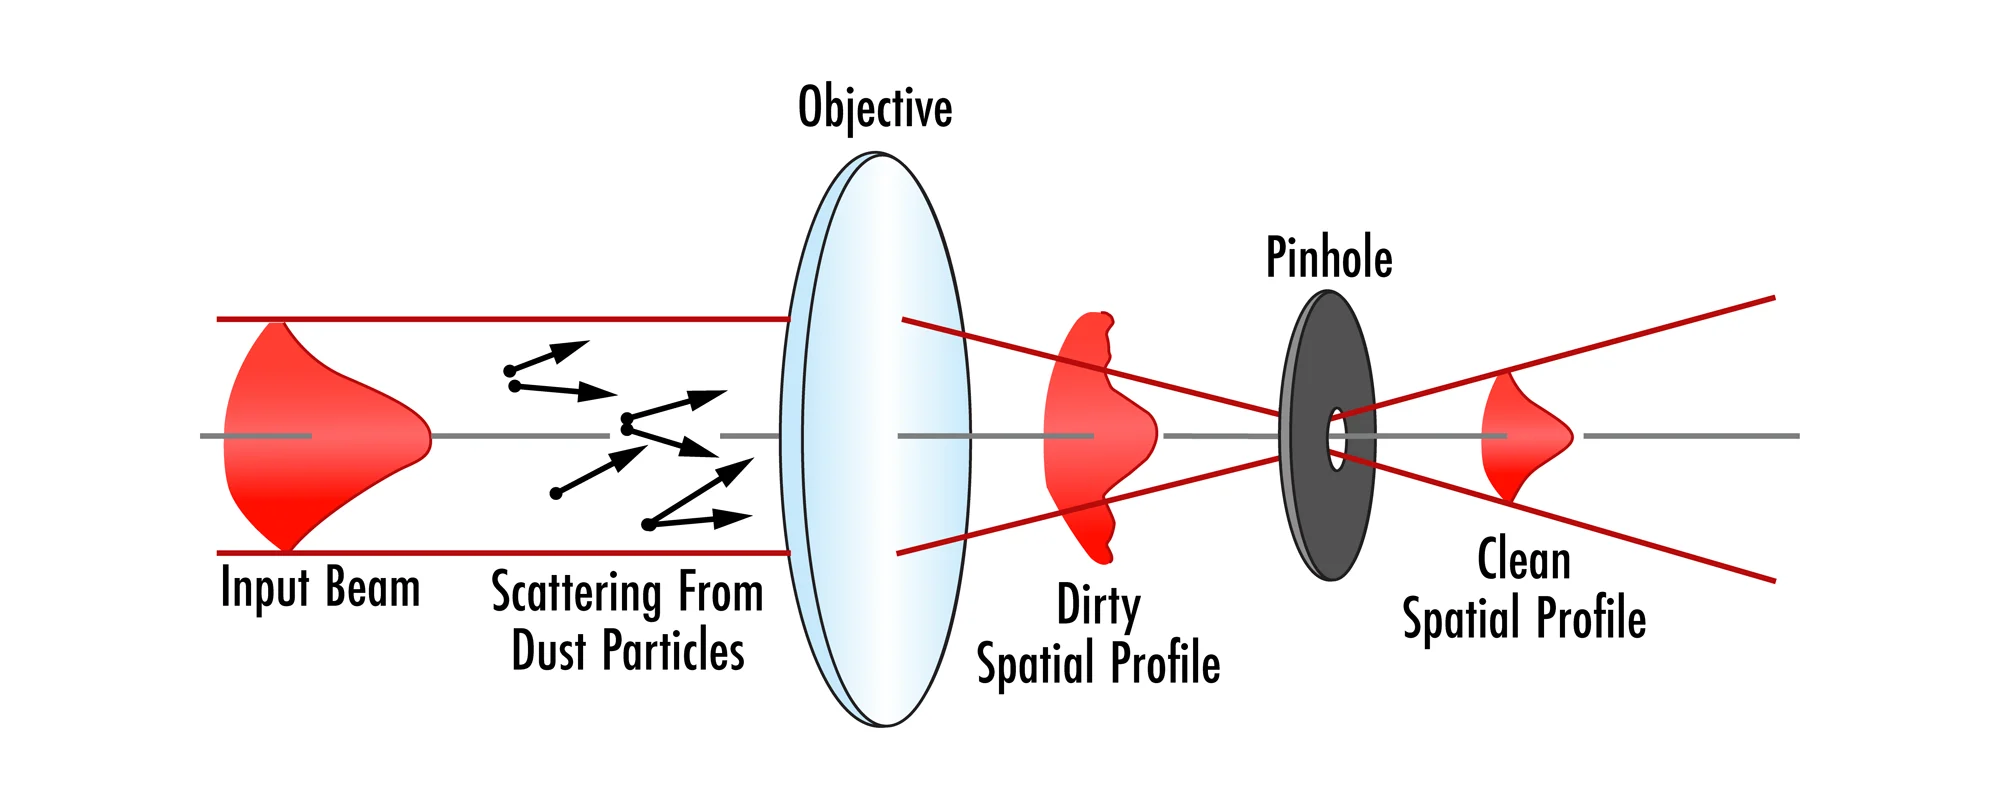

## 5.5 Transport to target
The beam at this point is ~40cm wide, making it fairly safe to operate with since the overall intensity is low. The final optical stage is the frequency conversion. At this point, our beam is still 1053 nm(infrared). Using 2 non-linear crystals, the beam is first converted down to 527 nm(green light) and then 351(UV). This is done because shorter wavelengths interact more efficiently with plasma and reduce instabilities. The efficiency of this crystals is typically around 70-80 percent and it is done at the end because there is a better conversion rate at higher intensity. 
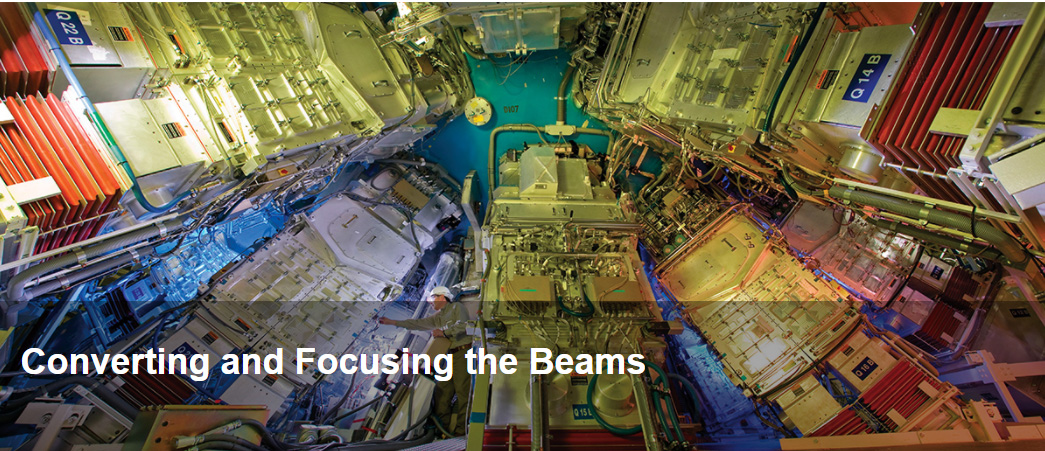

## 6. References

**[1]** Lawrence Livermore National Laboratory, **NIF Laser Configuration**.  
NIF User Guide page describing the 192-beam architecture and UV energy / peak-power capability.  
https://nifuserguide.llnl.gov/home/4-laser-system/41-nif-laser-configuration

**[2]** J. M. Di Nicola *et al.*, **Delivering laser performance conditions to enable fusion ignition at the National Ignition Facility**, *Fusion Engineering and Design* **205**, 114691 (2024).  
Useful modern overview of NIF operating requirements, including 1.8 MJ / 500 TW design goals and later performance improvements.  
https://doi.org/10.1016/j.fusengdes.2024.114691

**[3]** Lawrence Livermore National Laboratory, **Laser Glass**.  
Describes the Nd:phosphate glass slabs, flashlamp pumping, and amplifier sections.  
https://lasers.llnl.gov/about/seven-wonders/laser-glass

**[4]** Lawrence Livermore National Laboratory, **Final Optics**.  
Explains how NIF converts 1053-nm infrared light to 351-nm ultraviolet using KDP-based nonlinear optics.  
https://lasers.llnl.gov/about/how-nif-works/final-optics

**[5]** Lawrence Livermore National Laboratory, **Pulse Shaping**.  
Explains that requested target pulse shapes are converted to a master-oscillator waveform after accounting for gain saturation and frequency-conversion distortion.  
https://nifuserguide.llnl.gov/home/4-laser-system/44-pulse-shape-timing-prepulse/441-pulse-shaping

**[6]** Nobel Prize Outreach, **Popular information: The Nobel Prize in Physics 2018**.  
Accessible explanation of chirped-pulse amplification and why stretching a pulse allows safe amplification before compression.  
https://www.nobelprize.org/prizes/physics/2018/popular-information/

**[7]** Lawrence Livermore National Laboratory, **Advanced Laser Systems / ARC**.  
Overview of the ARC petawatt-class capability associated with NIF.  
https://lasers.llnl.gov/science/expanding-photonics-frontiers/advanced-laser-systems

**[8]** L. M. Frantz and J. S. Nodvik, **Theory of Pulse Propagation in a Laser Amplifier**, *Journal of Applied Physics* **34**, 2346–2349 (1963).  
Classic reference for gain saturation in pulsed laser amplifiers.  
https://doi.org/10.1063/1.1702744

**[9]** P. J. Wegner *et al.*, **NIF final optics system: frequency conversion and beam conditioning**, Proc. SPIE **5341** (2004).  
NIF final-optics details.  
https://doi.org/10.1117/12.553191

---